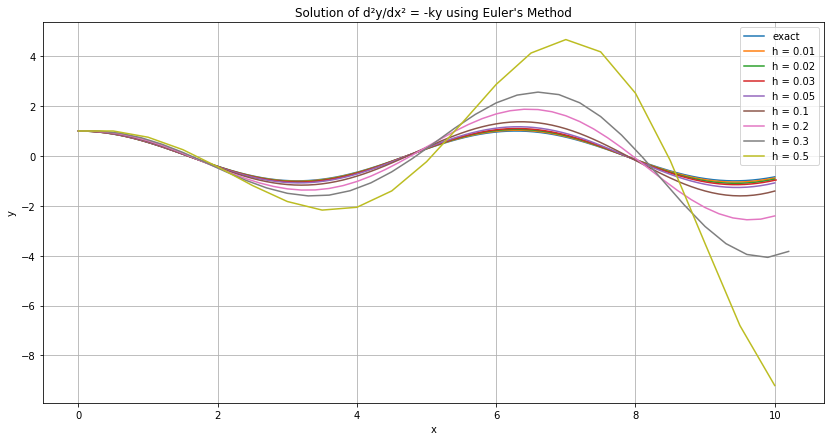

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Define the parameters

k = 1.0        # Constant in the equation (e.g., spring constant)
h_values = [0.01, 0.02, 0.03, 0.05, 0.1, 0.2, 0.3, 0.5]    # Step size
x_start = 0    # Start of the interval
x_end = 10     # End of the interval
y_0 = 1.0      # Initial condition for y
v_0 = 0.0      # Initial condition for dy/dx

# Create arrays to store x, y, and v values

x_exact = np.linspace(x_start, x_end, 1000)
y_exact = np.cos(np.sqrt(k) * x_exact)

# Plot the results

plt.figure(figsize=(14, 7))
plt.plot(x_exact, y_exact, label='exact')

for h in h_values:
    x_values = np.arange(x_start, x_end + h, h)
    y_values = np.zeros(len(x_values))
    v_values = np.zeros(len(x_values))
 
    y_values[0] = y_0
    v_values[0] = v_0
 
    for i in range(1, len(x_values)):
        y_n = y_values[i - 1]
        v_n = v_values[i - 1]
 
        y_values[i] = y_n + h * v_n
        v_values[i] = v_n + h * (-k * y_n)
 
    plt.plot(x_values, y_values, label=f'h = {h}')  

plt.xlabel('x')
plt.ylabel('y')
plt.title('Solution of d²y/dx² = -ky using Euler\'s Method')
plt.legend()
plt.grid()
plt.show()


## This becomes unstable at k = 1.0 when h = 2/sqrt(k) = 2.0
##
## It is becoming unstable as h grows, but slowly for such small h values
##
## As k increseases, the stability threshold decreases since it's an inverse relationship. This leads to
## blowing up at smaller h values.

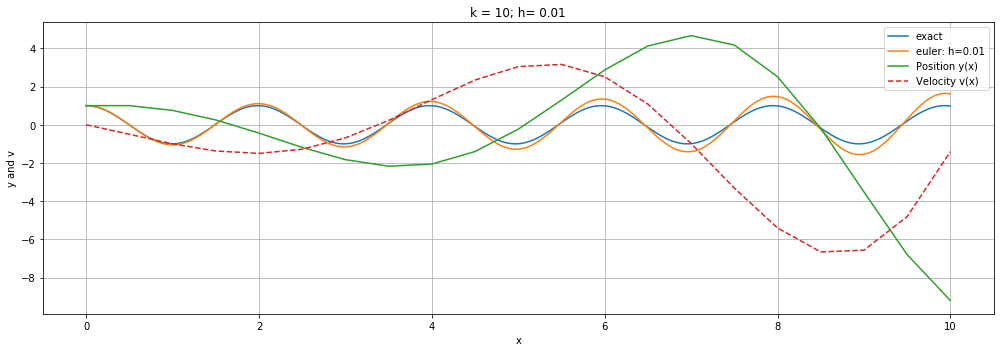

In [3]:
k2 = 10
h2 = 0.01
 
x_values2 = np.arange(x_start, x_end + h2, h2)
y_values2 = np.zeros(len(x_values2))
v_values2 = np.zeros(len(x_values2))
y_values2[0] = y_0
v_values2[0] = v_0
 
for i in range(1, len(x_values2)):
    y_n = y_values2[i - 1]
    v_n = v_values2[i - 1]
    y_values2[i] = y_n + h2 * v_n
    v_values2[i] = v_n + h2 * (-k2 * y_n)
    
x_exact2 = np.linspace(x_start, x_end, 2000)
y_exact2 = np.cos(np.sqrt(k2) * x_exact2)
 
plt.figure(figsize=(14, 5))
plt.plot(x_exact2, y_exact2, label='exact')
plt.plot(x_values2, y_values2, label=f'euler: h={h2}')
plt.title("k = 10; h= 0.01")
plt.plot(x_values, y_values, label='Position y(x)')
plt.plot(x_values, v_values, label='Velocity v(x)', linestyle='--')
plt.xlabel('x')
plt.ylabel('y and v')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

## At k = 10 and h = .01, Euler's method cannot solve this with larger h very reliably. The stability threshold
## is h = 2/sqrt(10) = 0.632, but since k is so large, larger h values will quickly diverge.